In [1]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

In [2]:
#  Define file paths for dataset, model, and supporting files
DATA_FILE = "data_balanced.csv"
MODEL_FILE = "model.pkl"
COLUMNS_FILE = "columns.pkl"
ENCODERS_FILE = "encoders.pkl"

In [3]:
#  Load dataset and display its shape (rows, columns)
print("Loading data...")
df = pd.read_csv(DATA_FILE, low_memory=False)
print(f"Data shape: {df.shape}")

Loading data...
Data shape: (66836, 43)


In [4]:
#  Validate that target column 'loanstatus' exists in dataset
if 'loanstatus' not in df.columns:
    print("Error: 'loanstatus' column not found in data!")
    exit(1)

In [5]:
#  Create target variable 'credit_risk' (1 = default, 0 = non-default)
df['credit_risk'] = df['loanstatus'].apply(
    lambda x: 1 if x == 'CHGOFF' else 0
)
print(f"Class distribution:\n{df['credit_risk'].value_counts()}")

Class distribution:
credit_risk
0    33418
1    33418
Name: count, dtype: int64


In [6]:
#Feature selection

In [7]:
#  Select relevant features for training the model
features = [
    'grossapproval',
    'terminmonths',
    'initialinterestrate',
    'businesstype',
    'naicsdescription',
    'jobssupported',
    'collateralind',
    'revolverstatus'
]
missing_features = [f for f in features if f not in df.columns]
if missing_features:
    print(f"Error: Missing features: {missing_features}")
    exit(1)

df = df[features + ['credit_risk']]
print (df)

       grossapproval  terminmonths  initialinterestrate businesstype  \
0              10000            84                 9.49  CORPORATION   
1              30000            31                 6.50  CORPORATION   
2             164000           203                 6.50  CORPORATION   
3              55600            46                 9.95  CORPORATION   
4             275000           116                 5.50  CORPORATION   
...              ...           ...                  ...          ...   
66831         179000             1                 7.02  CORPORATION   
66832         490000           120                 7.75  CORPORATION   
66833         250000             2                 6.00  CORPORATION   
66834         245000            60                 5.90  CORPORATION   
66835         145800            60                 6.60  CORPORATION   

                                        naicsdescription  jobssupported  \
0                 Painting and Wall Covering Contractors    

In [8]:
#  Handle missing values
print("Handling missing values...")
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna("Unknown")

print(f"Missing values after handling:\n{df.isnull().sum()}")

Handling missing values...
Missing values after handling:
grossapproval          0
terminmonths           0
initialinterestrate    0
businesstype           0
naicsdescription       0
jobssupported          0
collateralind          0
revolverstatus         0
credit_risk            0
dtype: int64


In [9]:
#  Encoding
print("Encoding categorical features...")
encoders = {}
categorical_cols = ['businesstype', 'naicsdescription', 'collateralind']

for col in categorical_cols:
    if col in df.columns:
        encoder = LabelEncoder()
        df[col] = encoder.fit_transform(df[col].astype(str))
        encoders[col] = encoder


Encoding categorical features...


In [10]:
# Save encoders
pickle.dump(encoders, open(ENCODERS_FILE, "wb"))

#  Features & target
X = df.drop('credit_risk', axis=1)
y = df['credit_risk']

In [11]:
# Save columns
pickle.dump(X.columns.tolist(), open(COLUMNS_FILE, "wb"))

print(f"Features for training: {X.columns.tolist()}")

#  Train-test split
print("Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Features for training: ['grossapproval', 'terminmonths', 'initialinterestrate', 'businesstype', 'naicsdescription', 'jobssupported', 'collateralind', 'revolverstatus']
Splitting data...
Training set: (53468, 8), Test set: (13368, 8)


In [12]:
#  Logistic Regression (MAIN MODEL)
print("Training Logistic Regression model...")

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("✅ Model trained successfully!")


Training Logistic Regression model...
✅ Model trained successfully!


In [13]:
#  Evaluation
print("Evaluating model...")
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.3).astype(int)  # Lower threshold

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Risk', 'High Risk']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Evaluating model...
Accuracy: 0.6443

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.85      0.35      0.50      6684
   High Risk       0.59      0.94      0.73      6684

    accuracy                           0.64     13368
   macro avg       0.72      0.64      0.61     13368
weighted avg       0.72      0.64      0.61     13368


Confusion Matrix:
[[2336 4348]
 [ 407 6277]]


In [14]:
# Train and evaluate Gradient Boosting Classifier (comparison only; does not alter existing outputs)
from sklearn.ensemble import GradientBoostingClassifier
print("Training Gradient Boosting Classifier...")
model_gb = GradientBoostingClassifier(random_state=42)
model_gb.fit(X_train, y_train)

print("Evaluating Gradient Boosting model...")
y_proba_gb = model_gb.predict_proba(X_test)[:, 1]
y_pred_gb = (y_proba_gb >= 0.3).astype(int)

from sklearn.metrics import roc_auc_score
accuracy_gb = accuracy_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_proba_gb)
print(f"Gradient Boosting Accuracy: {accuracy_gb:.4f}")
print(f"Gradient Boosting ROC AUC: {roc_auc_gb:.4f}")
print("\nClassification Report (Gradient Boosting):")
print(classification_report(y_test, y_pred_gb, target_names=['Low Risk', 'High Risk']))
print("\nConfusion Matrix (Gradient Boosting):")
print(confusion_matrix(y_test, y_pred_gb))

# Save Gradient Boosting model (separate artifact)
MODEL_GB_FILE = "model_gb.pkl"
print(f"Saving Gradient Boosting model to '{MODEL_GB_FILE}'...")
pickle.dump(model_gb, open(MODEL_GB_FILE, "wb"))
print("✅ Gradient Boosting model saved!")

Training Gradient Boosting Classifier...
Evaluating Gradient Boosting model...
Gradient Boosting Accuracy: 0.8972
Gradient Boosting ROC AUC: 0.9575

Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

    Low Risk       0.97      0.82      0.89      6684
   High Risk       0.85      0.97      0.90      6684

    accuracy                           0.90     13368
   macro avg       0.91      0.90      0.90     13368
weighted avg       0.91      0.90      0.90     13368


Confusion Matrix (Gradient Boosting):
[[5495 1189]
 [ 185 6499]]
Saving Gradient Boosting model to 'model_gb.pkl'...
✅ Gradient Boosting model saved!


Matplotlib is building the font cache; this may take a moment.


ROC plot saved to roc_comparison.png


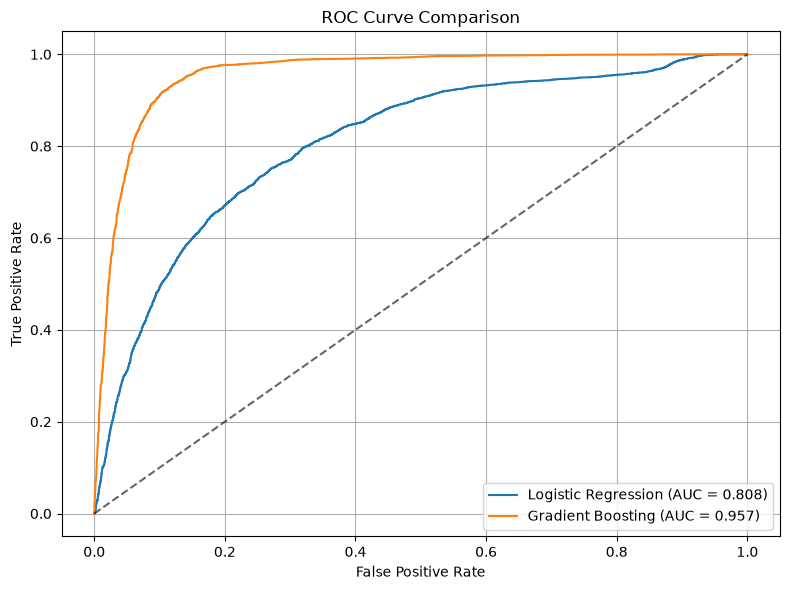

In [15]:
# Plot ROC curves for Logistic Regression and Gradient Boosting
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# compute ROC curves (uses y_proba from logistic and y_proba_gb from GB)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)
auc_lr = auc(fpr_lr, tpr_lr)
auc_gb = auc(fpr_gb, tpr_gb)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.3f})')
plt.plot([0,1], [0,1], 'k--', alpha=0.6)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
ROC_FILE = 'roc_comparison.png'
plt.savefig(ROC_FILE)
print(f'ROC plot saved to {ROC_FILE}')
plt.show()

In [16]:
#  Save model
print(f"Saving model to '{MODEL_FILE}'...")
pickle.dump(model, open(MODEL_FILE, "wb"))

print("✅ All files saved successfully!")

Saving model to 'model.pkl'...
✅ All files saved successfully!


In [17]:
# Hyperparameter tuning for Gradient Boosting (GridSearchCV)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}
gb = GradientBoostingClassifier(random_state=42)
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
grid = GridSearchCV(gb, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
print('Starting GridSearchCV (this may take a while)...')
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
best_gb = grid.best_estimator_
y_proba_gb_tuned = best_gb.predict_proba(X_test)[:,1]
y_pred_gb_tuned = (y_proba_gb_tuned >= 0.3).astype(int)
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
print(f'Tuned GB Accuracy: {accuracy_score(y_test, y_pred_gb_tuned):.4f}')
print(f'Tuned GB ROC AUC: {roc_auc_score(y_test, y_proba_gb_tuned):.4f}')
print('\nClassification Report (Tuned GB):')
print(classification_report(y_test, y_pred_gb_tuned, target_names=['Low Risk','High Risk']))
print('\nConfusion Matrix (Tuned GB):')
print(confusion_matrix(y_test, y_pred_gb_tuned))
pickle.dump(best_gb, open('model_gb_tuned.pkl', 'wb'))
print('Saved tuned model to model_gb_tuned.pkl')


Starting GridSearchCV (this may take a while)...
Fitting 4 folds for each of 24 candidates, totalling 96 fits
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Tuned GB Accuracy: 0.9137
Tuned GB ROC AUC: 0.9666

Classification Report (Tuned GB):
              precision    recall  f1-score   support

    Low Risk       0.97      0.86      0.91      6684
   High Risk       0.87      0.97      0.92      6684

    accuracy                           0.91     13368
   macro avg       0.92      0.91      0.91     13368
weighted avg       0.92      0.91      0.91     13368


Confusion Matrix (Tuned GB):
[[5734  950]
 [ 204 6480]]
Saved tuned model to model_gb_tuned.pkl
